AIM : To implement a Decision Tree classifier to predict Chronic Kidney Disease (CKD) using the CKD dataset and evaluate its performance.

Decision Tree is a supervised learning algorithm that builds a tree-like model by splitting data based on feature values to make predictions.

Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

Load Dataset

In [2]:
url = "https://raw.githubusercontent.com/Tanishq-Choudhary/Tanishq-Choudhary-23FE10CSE00664-ML-Lab-Sem-6/main/data/chronic_kidney_disease_full.csv"

df = pd.read_csv(url)

df.head()

,'age','bp','sg','al','su','rbc','pc','pcc','ba','bgr',...,'pcv','wbcc','rbcc','htn','dm','cad','appet','pe','ane','class'
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [19]:
df['class'] = df['class'].astype(str).str.strip()
df['class'] = df['class'].replace({'ckd\t': 'ckd', 'notckd\t': 'notckd'})

print(df['class'].value_counts())

class
0    250
2    149
1      1
Name: count, dtype: int64


Dataset Information

In [20]:
print("Dataset Shape:", df.shape)
print("Number of Features:", df.shape[1]-1)
print("Number of Samples:", df.shape[0])

df.info()

Dataset Shape: (400, 25)
Number of Features: 24
Number of Samples: 400
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     400 non-null    float64
 1   bp      400 non-null    float64
 2   sg      400 non-null    float64
 3   al      400 non-null    float64
 4   su      400 non-null    float64
 5   rbc     400 non-null    int64  
 6   pc      400 non-null    int64  
 7   pcc     400 non-null    int64  
 8   ba      400 non-null    int64  
 9   bgr     400 non-null    float64
 10  bu      400 non-null    float64
 11  sc      400 non-null    float64
 12  sod     400 non-null    float64
 13  pot     400 non-null    float64
 14  hemo    400 non-null    float64
 15  pcv     400 non-null    int64  
 16  wbcc    400 non-null    int64  
 17  rbcc    400 non-null    int64  
 18  htn     400 non-null    int64  
 19  dm      400 non-null    int64  
 20  cad  

Clean Column Names

In [21]:
df.columns = df.columns.str.strip().str.replace("'", "")

df.columns

Index(['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu',
       'sc', 'sod', 'pot', 'hemo', 'pcv', 'wbcc', 'rbcc', 'htn', 'dm', 'cad',
       'appet', 'pe', 'ane', 'class'],
      dtype='object')

Handle Missing Values

In [22]:
num_cols = df.select_dtypes(include=['float64','int64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

Fill missing values.

In [23]:
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

df.isnull().sum()

,0
age,0
bp,0
sg,0
al,0
su,0
rbc,0
pc,0
pcc,0
ba,0
bgr,0


In [44]:
df['class'] = df['class'].astype(str).str.strip()
df['class'] = df['class'].replace({
    'ckd': 1,
    'notckd': 0
})

Encode Categorical Variables

In [45]:
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,1.020,1.0,0.0,1,1,0,0,121.0,...,32,72,34,1,4,1,0,1,0,0
1,7.0,50.0,1.020,4.0,0.0,1,1,0,0,121.0,...,26,56,34,0,3,1,0,1,0,0
2,62.0,80.0,1.010,2.0,3.0,1,1,0,0,423.0,...,19,70,34,0,4,1,2,1,1,0
3,48.0,70.0,1.005,4.0,0.0,1,0,1,0,117.0,...,20,62,19,1,3,1,2,2,1,0
4,51.0,80.0,1.010,2.0,0.0,1,1,0,0,106.0,...,23,68,27,0,3,1,0,1,0,0


Feature Correlation Visualization

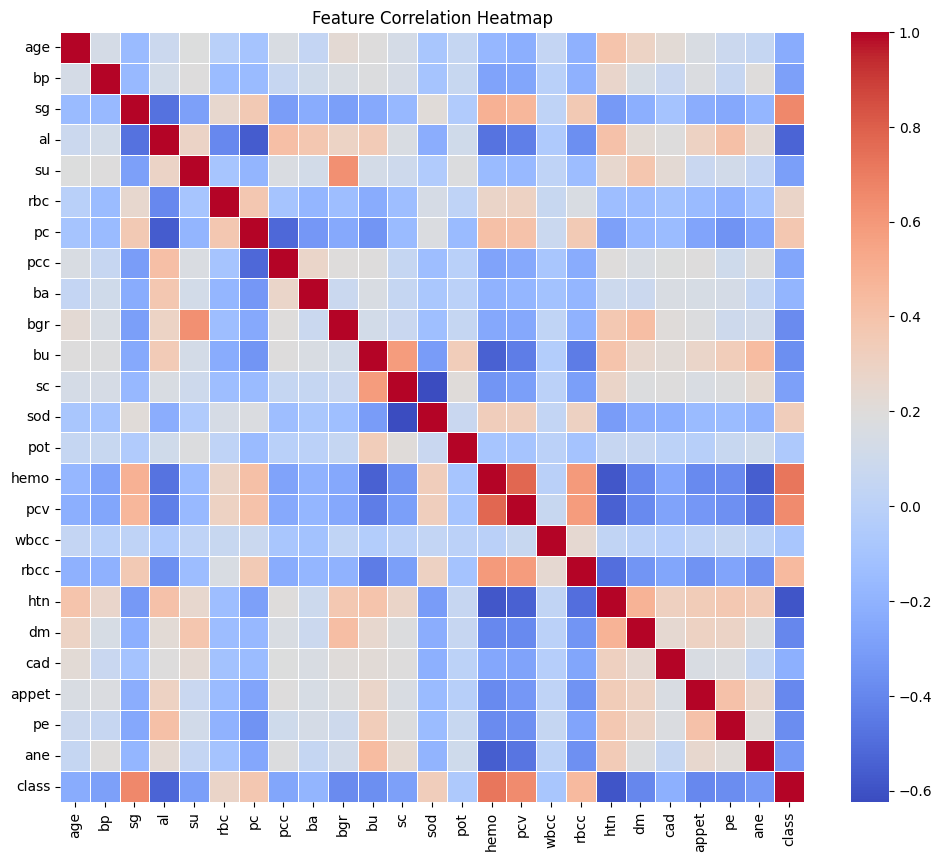

In [46]:
plt.figure(figsize=(12,10))

corr = df.corr()

sns.heatmap(corr, cmap='coolwarm', linewidths=0.5)

plt.title("Feature Correlation Heatmap")

plt.show()

Define Features and Target

In [47]:
X = df.drop('class', axis=1)
y = df['class']

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (400, 24)
Target vector shape: (400,)


In [54]:
df = df[df['class'] != 1]

Train Test Split

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (280, 24)
Testing data: (120, 24)


Train Decision Tree Model

In [63]:
dt_model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    random_state=42
)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)

Make Predictions

In [57]:
y_pred = dt_model.predict(X_test)

y_pred[:10]

array([0, 2, 0, 0, 0, 0, 2, 0, 2, 0])

Confusion Matrix

In [58]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[75  0  1]
 [ 0  0  1]
 [ 0  0 43]]


Classification Report

In [64]:
print(df['class'].unique())

[0 1]


In [60]:
print(df['class'].value_counts())

class
0    250
2    149
Name: count, dtype: int64


In [61]:
df['class'] = df['class'].replace({2:1})

In [62]:
print(df['class'].value_counts())

class
0    250
1    149
Name: count, dtype: int64


Accuracy Score

In [65]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.9833333333333333


Confusion Matrix Visualization

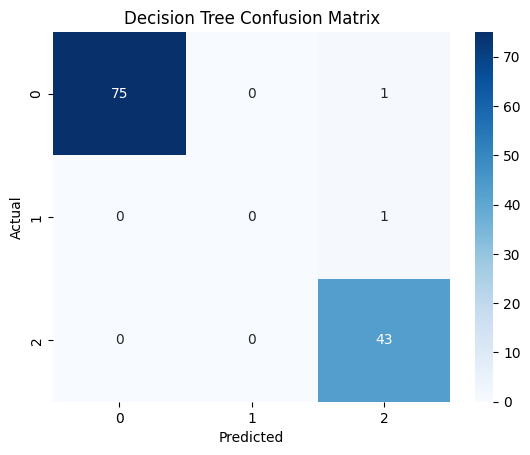

In [66]:
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")

plt.show()

Feature Importance

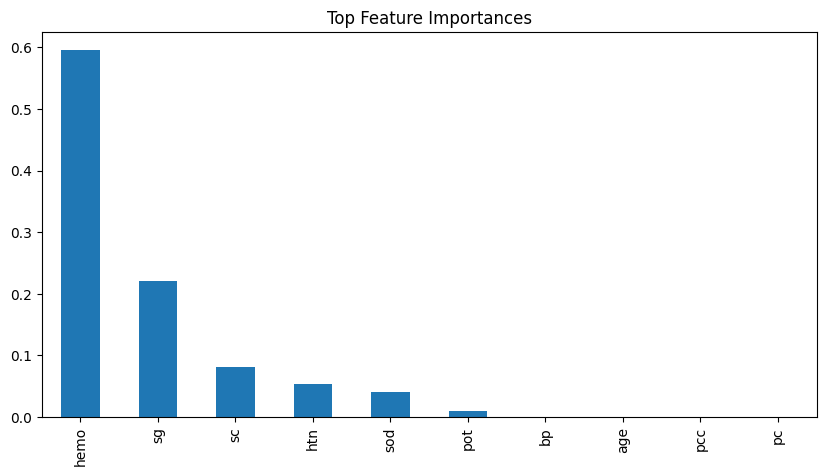

In [67]:
importance = pd.Series(
    dt_model.feature_importances_,
    index=X.columns
)

importance.sort_values(ascending=False).head(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top Feature Importances")
plt.show()

Visualize Decision Tree

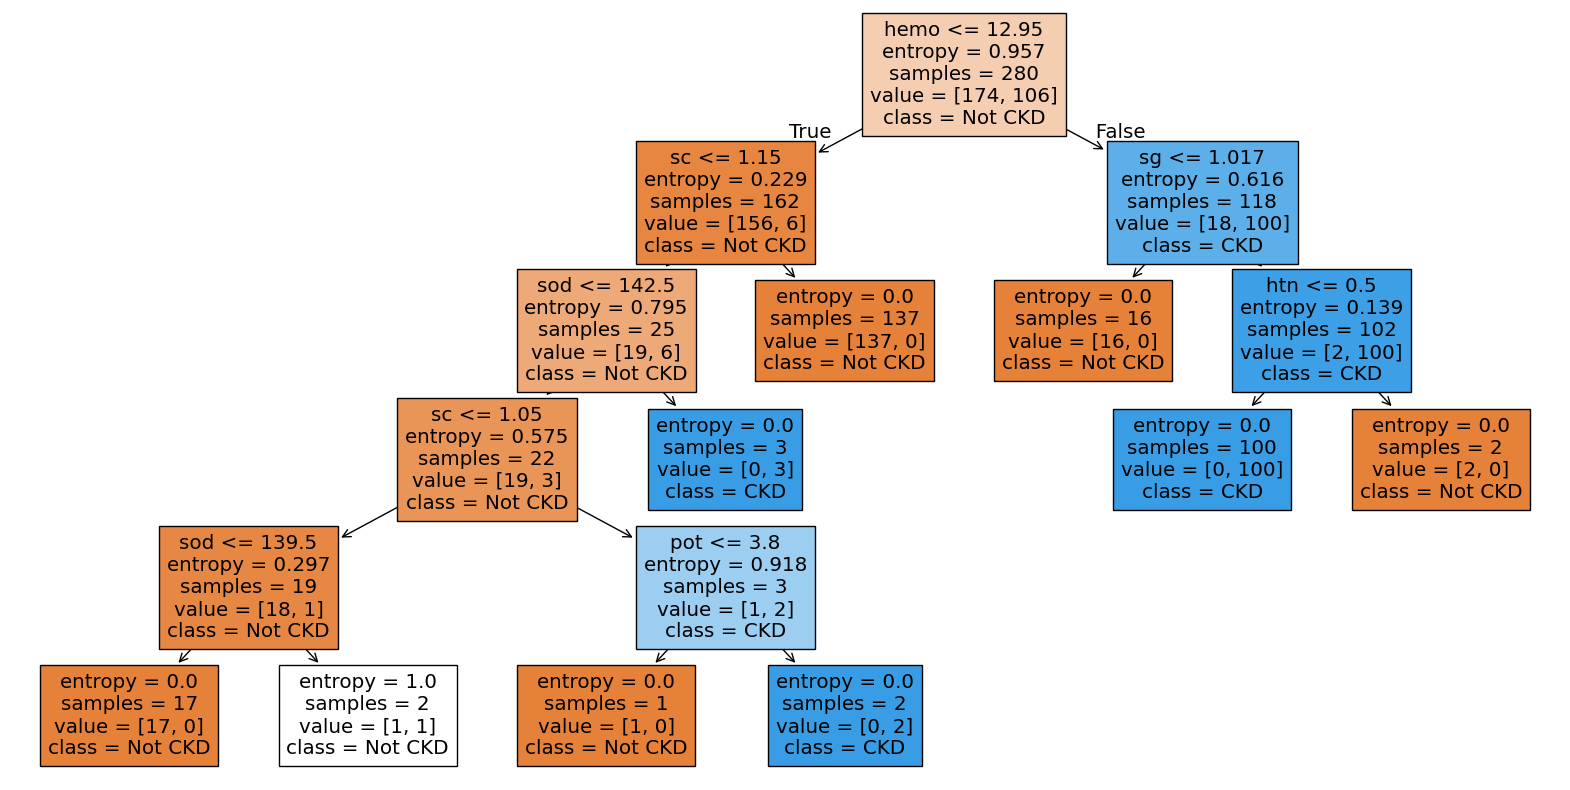

In [68]:
plt.figure(figsize=(20,10))

plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=['Not CKD','CKD'],
    filled=True
)

plt.show()

Conclusion

In this experiment, a Decision Tree classifier was applied to predict Chronic Kidney Disease using the CKD dataset. After preprocessing and encoding categorical variables, the model was trained and evaluated. The results show that Decision Trees are effective for medical classification problems due to their interpretability and ability to identify important features influencing the prediction.